In [6]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt


In [7]:
COLUMN_NAMES = [
    "gene_name", "wt_sequence", "mut_sequence",
    "wt_mrna_rep1", "wt_mrna_rep2", "wt_mrna_rep3",
    "mut_mrna_rep1", "mut_mrna_rep2", "mut_mrna_rep3",
    "wt_protein_rep1", "wt_protein_rep2", "wt_protein_rep3",
    "mut_protein_rep1", "mut_protein_rep2", "mut_protein_rep3",
    "wt_viability_rep1", "wt_viability_rep2", "wt_viability_rep3",
    "mut_viability_rep1", "mut_viability_rep2", "mut_viability_rep3"
]


In [8]:
def load_all_files(folder_path):
    if not os.path.exists(folder_path):
        raise FileNotFoundError("Folder not found: " + folder_path)

    all_rows  = []
    all_files = os.listdir(folder_path)

    for filename in all_files:
        if filename.endswith(".tsv") or filename.endswith(".txt"):
            filepath = folder_path + "/" + filename

            df = pd.read_csv(filepath, sep="\t", names=COLUMN_NAMES, skiprows=1)

            rows_as_lists = df.values.tolist()

            for row in rows_as_lists:
                wt  = str(row[1])
                mut = str(row[2])
                valid_dna = re.compile("^[ATCG]+$")

                if not valid_dna.match(wt) or not valid_dna.match(mut):
                    print("Skipping invalid sequence in:", filename)
                    continue

                all_rows.append(row)

    combined = pd.DataFrame(all_rows, columns=COLUMN_NAMES)
    return combined

data = load_all_files(r"D:/biotech assignment")
print("Total rows:", len(data))
data

Total rows: 24


,gene_name,wt_sequence,mut_sequence,wt_mrna_rep1,wt_mrna_rep2,wt_mrna_rep3,mut_mrna_rep1,mut_mrna_rep2,mut_mrna_rep3,wt_protein_rep1,...,wt_protein_rep3,mut_protein_rep1,mut_protein_rep2,mut_protein_rep3,wt_viability_rep1,wt_viability_rep2,wt_viability_rep3,mut_viability_rep1,mut_viability_rep2,mut_viability_rep3
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,2.617708e+01,16.735333,3.183135e+08,2.776962e+01,17.761754,11685.000000,...,37123.000000,11693.000000,26726.000000,37133.000000,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077
1,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,6.389135e+01,5.165643e+00,13.914518,6.275914e+01,5.012645e+00,13.013207,14317.000000,...,42445.000000,14334.000000,4914.000000,42448.000000,0.062666,0.090101,0.256835,0.074965,0.163613,0.220555
2,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1.629126e+00,2.097780e+01,7.266207,-3.674294e+00,-1.094399e+02,-5.597223,25803.000000,...,4047.000000,8711.000000,21503.000000,0.000000,0.528095,0.765748,0.273578,0.000000,0.000000,0.000000
3,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,3.619328e+00,7.207154e+00,1.347365,3.898224e+00,6.585581e+00,0.413255,44784.000000,...,3517.000000,44785.000000,32607.000000,3530.000000,0.412541,0.059328,0.476712,0.184925,0.017589,0.460078
4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1.398400e+00,1.745494e+00,4.394474,2.973012e+00,2.412630e+00,6.489425,29811.000000,...,45335.000000,54659.000000,55693.000000,55698.000000,0.829231,0.301918,0.795280,5.874721,6.243796,5.455045
5,Cairn3a2,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,2.529018e+01,2.711265e+00,48.099042,2.539605e+01,2.666513e+00,49.186680,25992.000000,...,31383.000000,26001.000000,27949.000000,31399.000000,0.633514,0.956889,0.518404,0.664322,0.970643,0.692276
6,Cairn6,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,2.084163e+01,3.676616e+01,5213.843993,2.274574e+01,3.577278e+01,5213.722502,48979.000000,...,27149.000000,48992.000000,33458.000000,27163.000000,0.925855,0.799526,0.801135,0.946808,0.806410,0.835041
7,Clach6,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,1.985791e+01,3.451715e+00,2.631587,1.783861e+01,3.045175e+00,3.017050,48988.000000,...,7210.000000,48994.000000,4939.000000,7221.000000,0.902357,0.554833,0.911485,0.884963,0.605348,1.001523
8,Dsgt9a1,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,9.898111e+00,2.371426e+00,101.458408,2.041802e+01,3.124716e+00,101.491889,25570.000000,...,10606.000000,41200.000000,42018.000000,25348.000000,0.637916,0.149896,0.124796,0.000000,0.000000,0.000000
9,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,3.167661e+00,3.178356e+06,3.828825,2.268305e+00,3.178356e+06,2.285579,10686.000000,...,48037.000000,10695.000000,639.000000,48051.000000,0.108788,0.568027,0.022040,0.286469,0.673888,0.136360


In [9]:
def get_mutation_type(wt, mut):
    
    if type(wt) != str or type(mut) != str:
        return "unknown"

    if wt == "" or mut == "":
        return "unknown"

    
    if len(mut) > len(wt):
        return "insertion"
    elif len(mut) < len(wt):
        return "deletion"
    else:
        return "substitution"


results = []
for i in range(len(data)):
    wt  = data["wt_sequence"][i]
    mut = data["mut_sequence"][i]

    answer = get_mutation_type(wt, mut)
    results.append(answer)

data["mutation_type"] = results
data

,gene_name,wt_sequence,mut_sequence,wt_mrna_rep1,wt_mrna_rep2,wt_mrna_rep3,mut_mrna_rep1,mut_mrna_rep2,mut_mrna_rep3,wt_protein_rep1,...,mut_protein_rep1,mut_protein_rep2,mut_protein_rep3,wt_viability_rep1,wt_viability_rep2,wt_viability_rep3,mut_viability_rep1,mut_viability_rep2,mut_viability_rep3,mutation_type
0,Ah3,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,TGCCCGTCGTCAGAGGGTGGACGGTTACTATCAACGTCCGCTTCCA...,3.183135e+08,2.617708e+01,16.735333,3.183135e+08,2.776962e+01,17.761754,11685.000000,...,11693.000000,26726.000000,37133.000000,0.261116,0.726898,0.633374,0.338555,0.750318,0.710077,substitution
1,Alli8,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,TTTACCAGAATCTATAACAGTATATGGCAAAATTCTCCCGCGTACT...,6.389135e+01,5.165643e+00,13.914518,6.275914e+01,5.012645e+00,13.013207,14317.000000,...,14334.000000,4914.000000,42448.000000,0.062666,0.090101,0.256835,0.074965,0.163613,0.220555,substitution
2,Anap7c1,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,GGGCGCATAGTAGGCAAGACACCTATTGCTAAAAAACGTCCTGGAC...,1.629126e+00,2.097780e+01,7.266207,-3.674294e+00,-1.094399e+02,-5.597223,25803.000000,...,8711.000000,21503.000000,0.000000,0.528095,0.765748,0.273578,0.000000,0.000000,0.000000,substitution
3,App1l8,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,ATCTTATCGTACACTATTAATAAACTAGCGCTGATTCGAGTCGCTC...,3.619328e+00,7.207154e+00,1.347365,3.898224e+00,6.585581e+00,0.413255,44784.000000,...,44785.000000,32607.000000,3530.000000,0.412541,0.059328,0.476712,0.184925,0.017589,0.460078,insertion
4,Avon4,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,TGAATCTAAGATTAAGTGGATATCGCCTTGACTTCTTTATCCATCC...,1.398400e+00,1.745494e+00,4.394474,2.973012e+00,2.412630e+00,6.489425,29811.000000,...,54659.000000,55693.000000,55698.000000,0.829231,0.301918,0.795280,5.874721,6.243796,5.455045,insertion
5,Cairn3a2,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,GCACTATGGAACAAATCTCCGTAGGATAGCCAGAGTAAATCGGCCT...,2.529018e+01,2.711265e+00,48.099042,2.539605e+01,2.666513e+00,49.186680,25992.000000,...,26001.000000,27949.000000,31399.000000,0.633514,0.956889,0.518404,0.664322,0.970643,0.692276,substitution
6,Cairn6,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,GATTGCTAGTGGTAGTGGTGGCCCGGGTCGCCGTCCGCCACTCTTT...,2.084163e+01,3.676616e+01,5213.843993,2.274574e+01,3.577278e+01,5213.722502,48979.000000,...,48992.000000,33458.000000,27163.000000,0.925855,0.799526,0.801135,0.946808,0.806410,0.835041,substitution
7,Clach6,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,AAATGACATCCTCCGGGGAACGATGCAGGCCCAGTAAGCCAATACT...,1.985791e+01,3.451715e+00,2.631587,1.783861e+01,3.045175e+00,3.017050,48988.000000,...,48994.000000,4939.000000,7221.000000,0.902357,0.554833,0.911485,0.884963,0.605348,1.001523,substitution
8,Dsgt9a1,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,ATAATCGCTGGTGTACTTCAAGTTACGACTTGAGTACGCATATCCA...,9.898111e+00,2.371426e+00,101.458408,2.041802e+01,3.124716e+00,101.491889,25570.000000,...,41200.000000,42018.000000,25348.000000,0.637916,0.149896,0.124796,0.000000,0.000000,0.000000,insertion
9,Ever6b6,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,AAGTTATTCTACGGGCCCTCTATTGAATAGATAACCCAGGGGCGTG...,3.167661e+00,3.178356e+06,3.828825,2.268305e+00,3.178356e+06,2.285579,10686.000000,...,10695.000000,639.000000,48051.000000,0.108788,0.568027,0.022040,0.286469,0.673888,0.136360,deletion


In [10]:
def get_mutation_region(wt, mut):

    if type(wt) != str or type(mut) != str:
        return "unknown"

    if wt == "" or mut == "":
        return "unknown"


    wt_promoter  = wt[:1000]
    wt_coding    = wt[1000:]
    mut_promoter = mut[:1000]
    mut_coding   = mut[1000:]

    promoter_changed = False
    coding_changed   = False

    # Check promoter region
    for i in range(len(wt_promoter)):
        if i >= len(mut_promoter):
            break
        if wt_promoter[i] != mut_promoter[i]:
            promoter_changed = True

    # Check coding region
    for i in range(len(wt_coding)):
        if i >= len(mut_coding):
            break
        if wt_coding[i] != mut_coding[i]:
            coding_changed = True

    if promoter_changed == True and coding_changed == True:
        return "both"
    elif promoter_changed == True:
        return "promoter"
    elif coding_changed == True:
        return "coding"
    else:
        return "unknown"


results = []
for i in range(len(data)):
    wt  = data["wt_sequence"][i]
    mut = data["mut_sequence"][i]

    answer = get_mutation_region(wt, mut)
    results.append(answer)

data["mutation_region"] = results
print(data[["gene_name", "mutation_type", "mutation_region"]])

   gene_name mutation_type mutation_region
0        Ah3  substitution        promoter
1      Alli8  substitution        promoter
2    Anap7c1  substitution        promoter
3     App1l8     insertion            both
4      Avon4     insertion            both
5   Cairn3a2  substitution        promoter
6     Cairn6  substitution        promoter
7     Clach6  substitution        promoter
8    Dsgt9a1     insertion          coding
9    Ever6b6      deletion            both
10    Everr1     insertion            both
11      Got9     insertion            both
12      Ist3      deletion            both
13    Ist9a2      deletion        promoter
14    Ist9a7  substitution        promoter
15     Ist9a      deletion            both
16   Jams9r2      deletion            both
17    Jok4a3  substitution        promoter
18        K2  substitution        promoter
19       Kl8  substitution        promoter
20   Nect1c1      deletion            both
21   Nect5r3      deletion            both
22   Pear9a

In [11]:
# mRNA averages 
wt_mrna_avg  = []
mut_mrna_avg = []

for i in range(len(data)):
    wt_rep1 = float(data["wt_mrna_rep1"][i])
    wt_rep2 = float(data["wt_mrna_rep2"][i])
    wt_rep3 = float(data["wt_mrna_rep3"][i])
    wt_avg  = (wt_rep1 + wt_rep2 + wt_rep3) / 3
    wt_mrna_avg.append(wt_avg)

    mut_rep1 = float(data["mut_mrna_rep1"][i])
    mut_rep2 = float(data["mut_mrna_rep2"][i])
    mut_rep3 = float(data["mut_mrna_rep3"][i])
    mut_avg  = (mut_rep1 + mut_rep2 + mut_rep3) / 3
    mut_mrna_avg.append(mut_avg)

data["wt_mrna_avg"]  = wt_mrna_avg
data["mut_mrna_avg"] = mut_mrna_avg

# Protein averages
wt_protein_avg = []
mut_protein_avg = []

for i in range(len(data)):
    wt_rep1 = float(data["wt_protein_rep1"][i])
    wt_rep2 = float(data["wt_protein_rep2"][i])
    wt_rep3 = float(data["wt_protein_rep3"][i])
    wt_avg = (wt_rep1 + wt_rep2 + wt_rep3) / 3
    wt_protein_avg.append(wt_avg)
    
    mut_rep1 = float(data["mut_protein_rep1"][i])
    mut_rep2 = float(data["mut_protein_rep2"][i])
    mut_rep3 = float(data["mut_protein_rep3"][i])
    mut_avg = (mut_rep1 + mut_rep2 + mut_rep3) / 3
    mut_protein_avg.append(mut_avg)

data["wt_protein_avg"]  = wt_protein_avg
data["mut_protein_avg"] = mut_protein_avg

# Viability averages
wt_viability_avg = []
mut_viability_avg = []

for i in range(len(data)):
    wt_rep1 = float(data["wt_viability_rep1"][i])
    wt_rep2 = float(data["wt_viability_rep2"][i])
    wt_rep3 = float(data["wt_viability_rep3"][i])
    wt_avg = (wt_rep1 + wt_rep2 + wt_rep3) / 3
    wt_viability_avg.append(wt_avg)
    
    mut_rep1 = float(data["mut_viability_rep1"][i])
    mut_rep2 = float(data["mut_viability_rep2"][i])
    mut_rep3 = float(data["mut_viability_rep3"][i])
    mut_avg = (mut_rep1 + mut_rep2 + mut_rep3) / 3
    mut_viability_avg.append(mut_avg)

data["wt_viability_avg"]  = wt_viability_avg
data["mut_viability_avg"] = mut_viability_avg


summary_cols = ["gene_name",
                "wt_mrna_avg", "mut_mrna_avg",
                "wt_protein_avg", "mut_protein_avg",
                "wt_viability_avg", "mut_viability_avg"]

summary = data[summary_cols]
summary

,gene_name,wt_mrna_avg,mut_mrna_avg,wt_protein_avg,mut_protein_avg,wt_viability_avg,mut_viability_avg
0,Ah3,1.061045e+08,1.061045e+08,25176.666667,25184.000000,0.540463,0.599650
1,Alli8,2.765717e+01,2.692833e+01,20556.333333,20565.333333,0.136534,0.153044
2,Anap7c1,9.957710e+00,-3.957048e+01,21147.666667,10071.333333,0.522474,0.000000
3,App1l8,4.057949e+00,3.632353e+00,26965.333333,26974.000000,0.316194,0.220864
4,Avon4,2.512790e+00,3.958356e+00,35318.333333,55350.000000,0.642143,5.857854
5,Cairn3a2,2.536683e+01,2.574975e+01,28437.666667,28449.666667,0.702936,0.775747
6,Cairn6,1.757151e+03,1.757414e+03,36524.333333,36537.666667,0.842172,0.862753
7,Clach6,8.647071e+00,7.966945e+00,20376.000000,20384.666667,0.789559,0.830611
8,Dsgt9a1,3.790932e+01,4.167821e+01,19030.333333,36188.666667,0.304203,0.000000
9,Ever6b6,1.059454e+06,1.059454e+06,19785.666667,19795.000000,0.232951,0.365572


In [12]:

viability_diff = []
mrna_diff = []
protein_diff = []

for i in range(len(data)):
    v_diff = data["mut_viability_avg"][i] - data["wt_viability_avg"][i]
    viability_diff.append(v_diff)
    
    m_diff = data["mut_mrna_avg"][i] - data["wt_mrna_avg"][i]
    mrna_diff.append(m_diff)
    
    p_diff = data["mut_protein_avg"][i] - data["wt_protein_avg"][i]
    protein_diff.append(p_diff)

data["viability_diff"] = viability_diff
data["mrna_diff"]      = mrna_diff
data["protein_diff"]   = protein_diff


summary = data[["gene_name", "mutation_type", "mutation_region",
                "viability_diff", "mrna_diff", "protein_diff"]]
summary

,gene_name,mutation_type,mutation_region,viability_diff,mrna_diff,protein_diff
0,Ah3,substitution,promoter,0.059187,1.083121,7.333333
1,Alli8,substitution,promoter,0.016510,-0.728842,9.000000
2,Anap7c1,substitution,promoter,-0.522474,-49.528187,-11076.333333
3,App1l8,insertion,both,-0.095330,-0.425596,8.666667
4,Avon4,insertion,both,5.215711,1.445566,20031.666667
5,Cairn3a2,substitution,promoter,0.072811,0.382921,12.000000
6,Cairn6,substitution,promoter,0.020581,0.263078,13.333333
7,Clach6,substitution,promoter,0.041053,-0.680126,8.666667
8,Dsgt9a1,insertion,coding,-0.304203,3.768895,17158.333333
9,Ever6b6,deletion,both,0.132621,-0.813637,9.333333


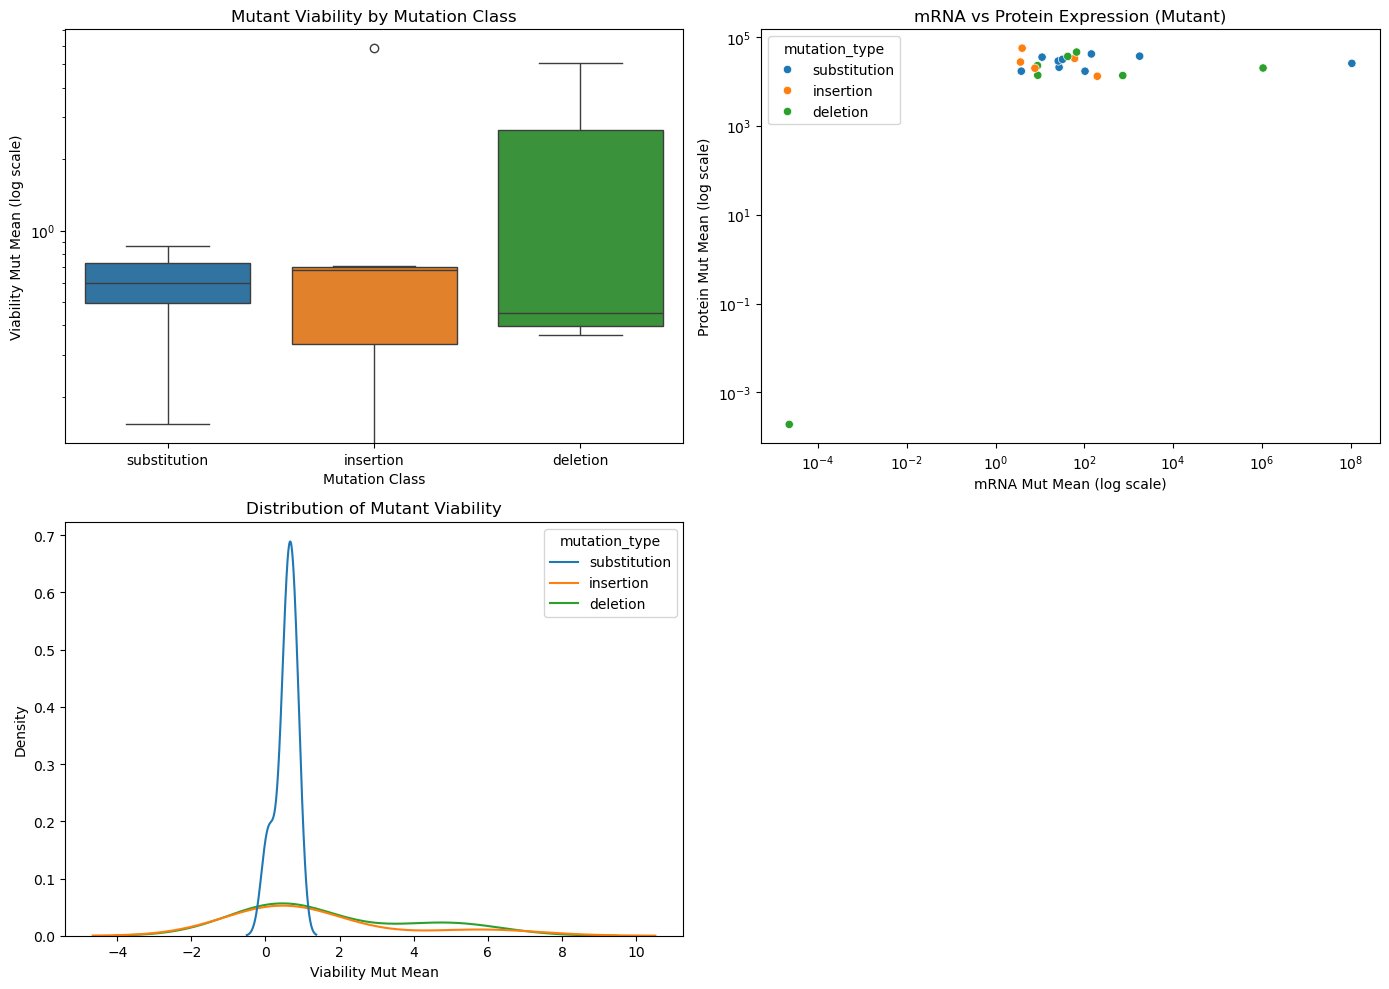

In [13]:

top5_genes = ["Ist9a2", "Avon4", "Nect1c1", "Anap7c1", "Dsgt9a1"]

import seaborn as sbn

plot_df = pd.DataFrame({
    "gene_name":     list(data["gene_name"]),
    "mutation_type": list(data["mutation_type"]),
    "wt_viability":  list(data["wt_viability_avg"]),
    "mut_viability": list(data["mut_viability_avg"]),
    "mut_mrna":      list(data["mut_mrna_avg"]),
    "mut_protein":   list(data["mut_protein_avg"])
})

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Panel 1 - Boxplot
sbn.boxplot(plot_df, x="mutation_type", y="mut_viability",
            hue="mutation_type", ax=ax[0, 0])
ax[0, 0].set_yscale("log")
ax[0, 0].set_title("Mutant Viability by Mutation Class")
ax[0, 0].set_xlabel("Mutation Class")
ax[0, 0].set_ylabel("Viability Mut Mean (log scale)")

# Panel 2 - Scatter plot
sbn.scatterplot(plot_df, x="mut_mrna", y="mut_protein",
                hue="mutation_type", ax=ax[0, 1])
ax[0, 1].set_xscale("log")
ax[0, 1].set_yscale("log")
ax[0, 1].set_title("mRNA vs Protein Expression (Mutant)")
ax[0, 1].set_xlabel("mRNA Mut Mean (log scale)")
ax[0, 1].set_ylabel("Protein Mut Mean (log scale)")

# Panel 3 - KDE plot
sbn.kdeplot(plot_df, x="mut_viability", hue="mutation_type", ax=ax[1, 0])
ax[1, 0].set_title("Distribution of Mutant Viability")
ax[1, 0].set_xlabel("Viability Mut Mean")
ax[1, 0].set_ylabel("Density")

# Hide empty panel
ax[1, 1].set_visible(False)

plt.tight_layout()
fig.savefig("my_plot.png")
plt.show()

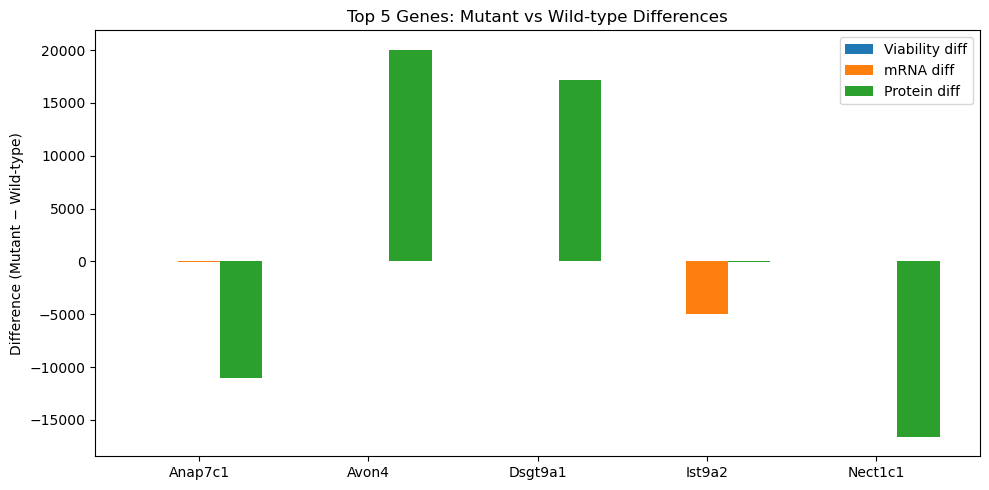

In [14]:
top5 = data[data["gene_name"].isin(top5_genes)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(top5))
width = 0.25

ax.bar([i - width for i in x], top5["viability_diff"], width=width, label="Viability diff")
ax.bar([i for i in x], top5["mrna_diff"], width=width, label="mRNA diff")
ax.bar([i + width for i in x], top5["protein_diff"], width=width, label="Protein diff")

ax.set_xticks(list(x))
ax.set_xticklabels(list(top5["gene_name"]))
ax.set_title("Top 5 Genes: Mutant vs Wild-type Differences")
ax.set_ylabel("Difference (Mutant − Wild-type)")
ax.legend()
plt.tight_layout()
plt.savefig("top5_bar.png")
plt.show()

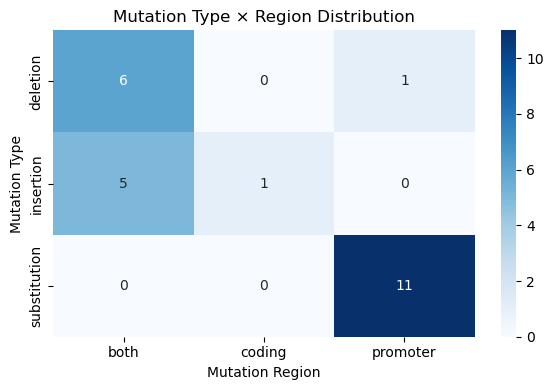

In [15]:
import seaborn as sbn

cross = pd.crosstab(data["mutation_type"], data["mutation_region"])

fig, ax = plt.subplots(figsize=(6, 4))
sbn.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Mutation Type × Region Distribution")
ax.set_xlabel("Mutation Region")
ax.set_ylabel("Mutation Type")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()